Mounted at /content/drive
Found 1002 images belonging to 2 classes.
Found 429 images belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 261s 4s/step - accuracy: 0.9162 - loss: 0.1817 - val_accuracy: 0.9580 - val_loss: 0.1034
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 19s 294ms/step - accuracy: 0.9691 - loss: 0.0849 - val_accuracy: 0.9557 - val_loss: 0.0903
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 289ms/step - accuracy: 0.9750 - loss: 0.0654 - val_accuracy: 0.9650 - val_loss: 0.0867
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 293ms/step - accuracy: 0.9820 - loss: 0.0434 - val_accuracy: 0.9580 - val_loss: 0.0940
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 19s 307ms/step - accuracy: 0.9870 - loss: 0.0347 - val_accuracy: 0.9441 - val_loss: 0.1715
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.9441 - loss: 0.1715

Test Accuracy: 94.41 %
Test Loss: 0.1715
27/27 ━━━━━━━━━━━━━━━━━━━━ 12s 284ms/step

Classification Report:

              precisi

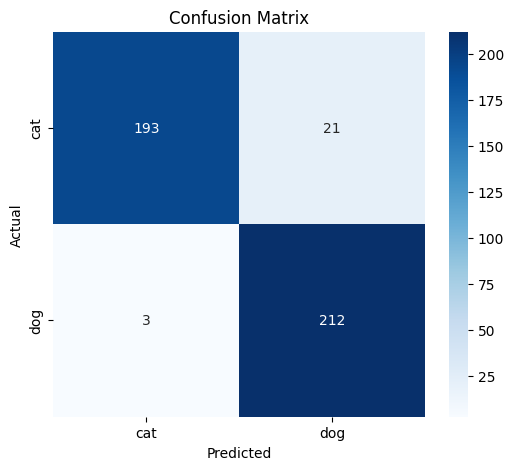

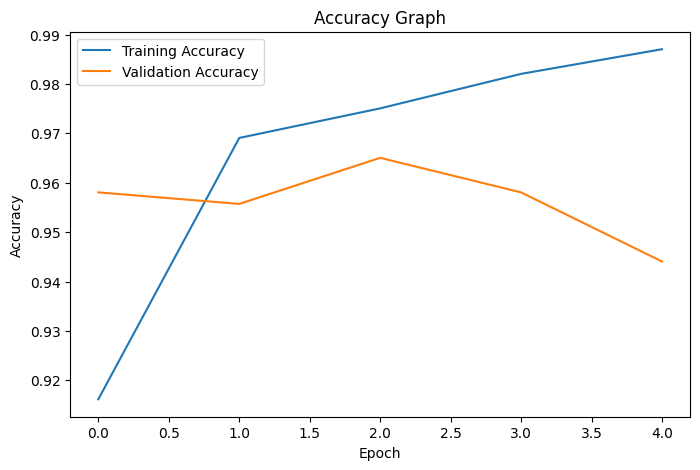

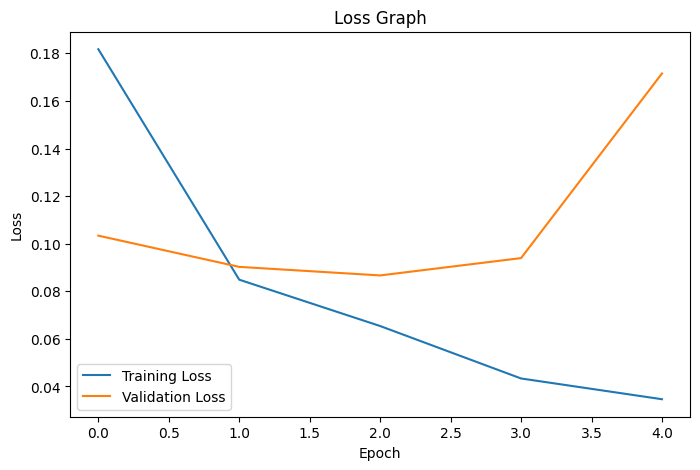


Upload an image of Cat or Dog


Saving download.jpeg to download.jpeg


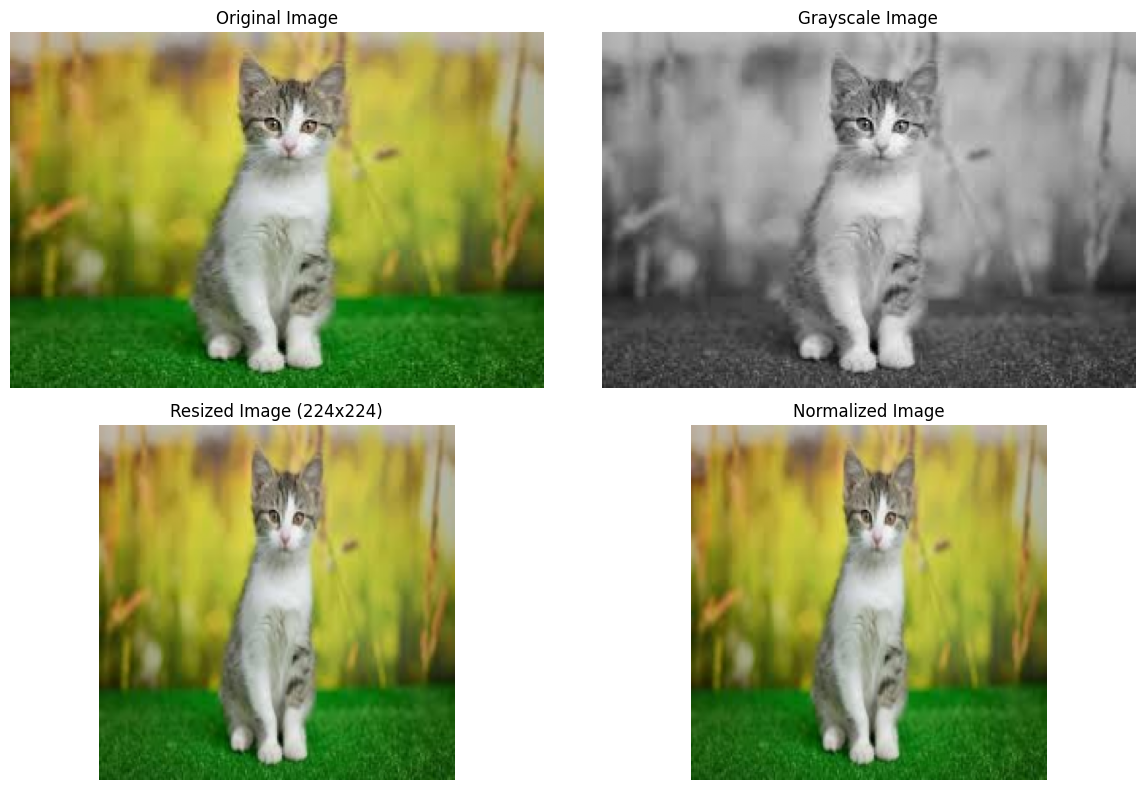

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step



Prediction Confidence: [[9.999124e-01 8.758522e-05]]
Final Prediction: CAT

Model Saved Successfully


In [1]:
# Install libraries
!pip install -q scikit-learn seaborn

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os

from google.colab import drive, files

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import confusion_matrix, classification_report

# ============================================================
# 2. MOUNT GOOGLE DRIVE
# ============================================================
drive.mount('/content/drive')

# ============================================================
# 3. DATASET PATH
# ============================================================
train_path = '/content/drive/MyDrive/dataset/train'
test_path  = '/content/drive/MyDrive/dataset/test'

# ============================================================
# 4. IMAGE PREPROCESSING
# ============================================================
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical'
)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)

# ============================================================
# 5. LOAD PRETRAINED MODEL
# ============================================================
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

# ============================================================
# 6. BUILD MODEL
# ============================================================
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(2, activation='softmax')
])

# ============================================================
# 7. COMPILE MODEL
# ============================================================
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ============================================================
# 8. TRAIN MODEL
# ============================================================
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

# ============================================================
# 9. EVALUATE MODEL
# ============================================================
loss, accuracy = model.evaluate(test_data)

print("\nTest Accuracy:", round(accuracy*100,2), "%")
print("Test Loss:", round(loss,4))

# ============================================================
# 10. PREDICTIONS FOR METRICS
# ============================================================
pred = model.predict(test_data)
pred_classes = np.argmax(pred, axis=1)
true_classes = test_data.classes

class_names = ['cat', 'dog']

# ============================================================
# 11. CLASSIFICATION REPORT
# ============================================================
print("\nClassification Report:\n")
print(classification_report(true_classes, pred_classes, target_names=class_names))

# ============================================================
# 12. CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ============================================================
# 13. ACCURACY GRAPH
# ============================================================
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Graph")
plt.legend()
plt.show()

# ============================================================
# 14. LOSS GRAPH
# ============================================================
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Graph")
plt.legend()
plt.show()

# ============================================================
# 15. UPLOAD INPUT IMAGE FOR TESTING
# ============================================================
print("\nUpload an image of Cat or Dog")
uploaded = files.upload()

img_name = list(uploaded.keys())[0]

# ============================================================
# 16. IMAGE PROCESSING STAGES
# ============================================================
img = cv2.imread(img_name)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Resize
resized = cv2.resize(img_rgb, (224,224))

# Normalize
normalized = resized / 255.0

# ============================================================
# 17. DISPLAY PROCESSING STAGES
# ============================================================
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(resized)
plt.title("Resized Image (224x224)")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(normalized)
plt.title("Normalized Image")
plt.axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# 18. FINAL PREDICTION
# ============================================================
input_img = np.expand_dims(normalized, axis=0)

prediction = model.predict(input_img)
predicted_class = np.argmax(prediction)

print("\nPrediction Confidence:", prediction)

if predicted_class == 0:
    print("Final Prediction: CAT")
else:
    print("Final Prediction: DOG")

# ============================================================
# 19. SAVE MODEL
# ============================================================
model.save("cat_dog_classifier.h5")
print("\nModel Saved Successfully")